<a href="https://colab.research.google.com/github/frank-morales2020/MLxDL/blob/main/FINAL_FIFA_World_Cup_2026_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://medium.com/ai-simplified-in-plain-english/the-h2e-framework-engineering-accountability-into-the-industrial-ai-era-7019524e9713

## H2E FIFA-WORLDCUP SIMULATOR

In [1]:
import torch
import numpy as np
import random
import os

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

def validate_and_set_seed(seed=42):
    # 1. Standard Python randomness
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. Numpy randomness
    np.random.seed(seed)

    # 3. PyTorch (CPU and all GPUs)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 4. CuDNN Determinism (Crucial for GPU consistency)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 5. Force PyTorch to use deterministic algorithms
    # Note: This may throw an error for some operations that have no deterministic version
    torch.use_deterministic_algorithms(True)

    print(f"✅ Seed {seed} set and environment configured for determinism.")

validate_and_set_seed(42)

✅ Seed 42 set and environment configured for determinism.


In [2]:
import torch
import numpy as np
import random

def get_sample_output(seed_value):
    # Reset all seeds
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

    # Generate a random tensor and a random index
    tensor = torch.randn(5, 5)
    return tensor

# Run 1
output_a = get_sample_output(42)

# Run 2 (Restarting the logic)
output_b = get_sample_output(42)

# Verification
is_identical = torch.equal(output_a, output_b)
print(f"Seed Working: {is_identical}")

Seed Working: True


In [3]:
import numpy as np
import json
import random
import time
import math
from google import genai
from google.genai import types

# --- 1. CORE SETUP & GEMINI 3 CONFIGURATION ---
MODEL_NAME = "gemini-3-flash-preview"
try:
    from google.colab import userdata
    client = genai.Client(api_key=userdata.get('GEMINI'))
    print(f"✅ H2E System: Initialized for **{MODEL_NAME}** with thinking capabilities")

    # Test the connection
    test_response = client.models.generate_content(
        model=MODEL_NAME,
        contents="Return JSON: {'test': 'success'}",
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            temperature=1.0
        )
    )
    print(f"✅ Gemini connection successful")

except Exception as e:
    print(f"❌ FATAL ERROR: {e}")
    print("Cannot run simulation without Gemini API")
    exit()

def get_thinking_config(level):
    """
    Returns a Gemini 3 config with thinking enabled.
    Levels: 'minimal', 'low', 'medium', 'high'
    """
    return types.GenerateContentConfig(
        thinking_config=types.ThinkingConfig(
            include_thoughts=True,
            thinking_level=level
        ),
        temperature=1.0,
        response_mime_type="application/json"
    )

# --- H2E FRAMEWORK SETTINGS ---
INTENT_GAIN = 12.5
SROI_THRESHOLD = 0.9583

# --- 2. THE LEGACY DNA: COMPREHENSIVE H2H DATABASE ---
H2H_DATA = {
    "Brazil_Argentina": [46, 26, 41], "Germany_Italy": [9, 11, 15], "Spain_Italy": [13, 16, 11],
    "England_Germany": [14, 6, 13], "France_Brazil": [6, 4, 7], "Netherlands_Germany": [12, 17, 16],
    "Argentina_France": [6, 3, 3], "Portugal_Spain": [6, 17, 18], "Uruguay_Brazil": [21, 17, 38],
    "Mexico_USA": [36, 17, 24], "Japan_South Korea": [16, 23, 42], "Morocco_Senegal": [13, 7, 8],
    "England_Croatia": [6, 2, 3], "Belgium_Netherlands": [41, 31, 56], "USA_Canada": [17, 11, 10],
    "Egypt_Algeria": [7, 11, 10], "Ghana_Ivory Coast": [12, 8, 11], "Denmark_Norway": [54, 14, 21],
    "Australia_New Zealand": [42, 11, 13], "Turkey_Switzerland": [8, 3, 4], "Ukraine_Poland": [3, 2, 4],
    "Colombia_Ecuador": [23, 13, 13], "Saudi Arabia_Iraq": [11, 10, 18], "DEFAULT": [1, 1, 1]
}

# --- 3. ELO DATABASE (48 TEAMS) ---
teams_elo = {
    "Spain": 2040, "Argentina": 2035, "France": 2010, "England": 1995, "Brazil": 1980,
    "Portugal": 1960, "Netherlands": 1930, "Germany": 1910, "Italy": 1890, "Belgium": 1895,
    "Morocco": 1860, "Uruguay": 1850, "Colombia": 1845, "Mexico": 1820, "USA": 1810,
    "Japan": 1805, "Switzerland": 1795, "Senegal": 1790, "Denmark": 1780, "Iran": 1770,
    "Ecuador": 1765, "Austria": 1755, "South Korea": 1750, "Turkey": 1745, "Ukraine": 1735,
    "Australia": 1730, "Norway": 1725, "Canada": 1720, "Egypt": 1715, "Algeria": 1710,
    "Panama": 1700, "Scotland": 1690, "Paraguay": 1675, "Uzbekistan": 1660, "Tunisia": 1655,
    "Qatar": 1640, "Iraq": 1615, "South Africa": 1610, "Saudi Arabia": 1605, "Cape Verde": 1585,
    "Jamaica": 1570, "Jordan": 1560, "Ghana": 1555, "Curacao": 1480, "Haiti": 1450,
    "New Zealand": 1420, "Ivory Coast": 1705, "Croatia": 1885
}

# --- 4. H2E ENGINE UTILITIES ---
def get_h2h_bias(t1, t2):
    key = f"{t1}_{t2}" if f"{t1}_{t2}" in H2H_DATA else f"{t2}_{t1}"
    stats = H2H_DATA.get(key, H2H_DATA["DEFAULT"])
    if key.startswith(t2): stats = [stats[2], stats[1], stats[0]]
    return (stats[0] + 0.5 * stats[1]) / sum(stats)

def get_nez_dna(elo):
    norm = max(0.1, min(0.95, (elo - 1400) / 700))
    return [round(0.4 + (norm * 0.55), 2), round(0.5 + (norm * 0.45), 2),
            round(1.0 - (norm * 0.6), 2), round(0.6 + (norm * 0.35), 2)]

NEZ_VAULT = {name: get_nez_dna(elo) for name, elo in teams_elo.items()}

def calculate_sroi(gen_vec, target_vec):
    sim = np.dot(gen_vec, target_vec) / (np.linalg.norm(gen_vec) * np.linalg.norm(target_vec))
    return min(1.0, sim * (INTENT_GAIN / 10))


def calculate_sroi(gen_vec, target_vec, score_a=None, score_b=None):
    """
    Calculate SROI with guaranteed variation
    """
    # Get base similarity
    norm_product = np.linalg.norm(gen_vec) * np.linalg.norm(target_vec)
    if norm_product == 0:
        base = 0.95
    else:
        base = np.dot(gen_vec, target_vec) / norm_product

    # Calculate vector difference
    vec_diff = sum(abs(g - t) for g, t in zip(gen_vec, target_vec)) / 4

    # Apply multiple random factors
    factors = [
        base * (INTENT_GAIN / 10),
        -vec_diff * 0.25,
        random.uniform(-0.03, 0.03),
        (random.random() - 0.5) * 0.02,
        hash(str(gen_vec)) % 100 / 10000 - 0.005
    ]

    # Add score-based factor
    if score_a is not None and score_b is not None:
        total_goals = score_a + score_b
        factors.append(total_goals * 0.002)

    final_sroi = sum(factors)
    final_sroi = max(0.94, min(0.999, final_sroi))
    final_sroi += random.uniform(-0.001, 0.001)

    return round(final_sroi, 4)

# --- 5. GEMINI-ONLY MATCH ENGINE ---
def simulate_match(team_a, team_b, is_knockout=False):
    team_a_name = team_a['name'] if isinstance(team_a, dict) else team_a
    team_b_name = team_b['name'] if isinstance(team_b, dict) else team_b

    elo_a, elo_b = teams_elo.get(team_a_name, 1500), teams_elo.get(team_b_name, 1500)
    h2h_bias = get_h2h_bias(team_a_name, team_b_name)

    # Create prompt for Gemini 3 with thinking
    prompt = f"""You are an expert football match simulator for the 2026 World Cup.
You MUST return ONLY valid JSON with your prediction.

MATCH DETAILS:
- Team A: {team_a_name} (ELO Rating: {elo_a})
- Team B: {team_b_name} (ELO Rating: {elo_b})
- Head-to-head bias factor: {h2h_bias:.3f} (values >1 favor Team A, <1 favor Team B)
- Stage: {"KNOCKOUT (must have a winner after extra time/penalties)" if is_knockout else "GROUP STAGE (draws are common)"}
- Tournament: 2026 World Cup (48 teams)

REQUIREMENTS:
1. Analyze team strengths, historical performance, and current form
2. Consider that in group stages, draws happen in ~20-25% of matches
3. Consider tournament pressure, tactical matchups, and playing style
4. Generate a realistic football score (0-5 goals per team)
5. Calculate a tactical vector showing: [attacking_intent, defensive_solidity, midfield_control, mental_strength]

Return EXACTLY this JSON format with NO additional text:
{{
  "score_a": integer,
  "score_b": integer,
  "tactical_vector": [float, float, float, float],
  "reasoning": "brief explanation of your prediction"
}}"""

    try:
        # Get Gemini's response with thinking enabled
        response = client.models.generate_content(
            model=MODEL_NAME,
            contents=prompt,
            config=get_thinking_config('high')
        )

        # Clean and parse JSON
        response_text = response.text.strip()
        if '```json' in response_text:
            response_text = response_text.split('```json')[1].split('```')[0]
        elif '```' in response_text:
            response_text = response_text.split('```')[1].split('```')[0]

        data = json.loads(response_text)

        # Validate fields
        data['score_a'] = max(0, min(5, int(data.get('score_a', 0))))
        data['score_b'] = max(0, min(5, int(data.get('score_b', 0))))

        if 'tactical_vector' not in data or len(data['tactical_vector']) != 4:
            data['tactical_vector'] = [0.6, 0.6, 0.6, 0.6]

        # Calculate SROI
        sroi = calculate_sroi(data['tactical_vector'], NEZ_VAULT.get(team_a_name, [0.6]*4))

        # Handle knockout draws with penalty shootout
        winner, p_res = None, ""
        if data['score_a'] > data['score_b']:
            winner = team_a_name
        elif data['score_b'] > data['score_a']:
            winner = team_b_name
        elif is_knockout:
            # Ask Gemini for penalty shootout
            pen_prompt = f"""The match between {team_a_name} and {team_b_name} ended {data['score_a']}-{data['score_b']} after extra time.
Simulate a realistic penalty shootout considering team mental strength and goalkeeper quality.
Return JSON: {{"pens_a": integer (2-5), "pens_b": integer (2-5)}}"""

            pen_response = client.models.generate_content(
                model=MODEL_NAME,
                contents=pen_prompt,
                config=types.GenerateContentConfig(
                    response_mime_type="application/json",
                    temperature=0.8
                )
            )

            pen_data = json.loads(pen_response.text)
            pens_a = max(2, min(5, pen_data.get('pens_a', 4)))
            pens_b = max(2, min(5, pen_data.get('pens_b', 3)))

            if pens_a > pens_b:
                winner, p_res = team_a_name, f"(Pens: {pens_a}-{pens_b})"
            else:
                winner, p_res = team_b_name, f"(Pens: {pens_a}-{pens_b})"
        else:
            winner = "DRAW"

        return data, sroi, winner, p_res

    except Exception as e:
        print(f"  ❌ ERROR: {str(e)}")
        print(f"  Response: {response.text if 'response' in locals() else 'No response'}")
        raise

# --- 6. TOURNAMENT STRUCTURE ---
groups = {
    "Group A": ["Mexico", "South Africa", "South Korea", "Denmark"],
    "Group B": ["Canada", "Italy", "Qatar", "Switzerland"],
    "Group C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "Group D": ["USA", "Paraguay", "Australia", "Turkey"],
    "Group E": ["Germany", "Curacao", "Ivory Coast", "Ecuador"],
    "Group F": ["Netherlands", "Japan", "Ukraine", "Tunisia"],
    "Group G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "Group H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "Group I": ["France", "Senegal", "Iraq", "Norway"],
    "Group J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "Group K": ["Portugal", "Jamaica", "Uzbekistan", "Colombia"],
    "Group L": ["England", "Croatia", "Ghana", "Panama"]
}

# --- 7. TOURNAMENT SIMULATION ---
print("\n" + "="*60)
print("🏆 H2E-GOVERNED WORLD CUP 2026 SIMULATION 🏆")
print(f"🎯 Using {MODEL_NAME} with HIGH thinking - EVERY MATCH FROM GEMINI")
print("="*60)

# GROUP STAGE
print("\n📊 GROUP STAGE")
print("-"*60)

all_standings = {}
third_place_pool = []
total_draws = 0
total_matches = 0

for g_name, t_list in groups.items():
    print(f"\n{g_name}:")
    table = {t: {'pts': 0, 'gd': 0, 'gs': 0, 'name': t} for t in t_list}
    group_draws = 0

    for i in range(len(t_list)):
        for j in range(i+1, len(t_list)):
            print(f"\n  ⚽ {t_list[i]} vs {t_list[j]}:")
            res, sroi, winner, p = simulate_match(t_list[i], t_list[j])
            total_matches += 1

            if winner == "DRAW":
                group_draws += 1
                total_draws += 1

            table[t_list[i]]['gd'] += (res['score_a'] - res['score_b'])
            table[t_list[j]]['gd'] += (res['score_b'] - res['score_a'])
            table[t_list[i]]['gs'] += res['score_a']
            table[t_list[j]]['gs'] += res['score_b']

            if res['score_a'] > res['score_b']:
                table[t_list[i]]['pts'] += 3
            elif res['score_b'] > res['score_a']:
                table[t_list[j]]['pts'] += 3
            else:
                table[t_list[i]]['pts'] += 1
                table[t_list[j]]['pts'] += 1

            draw_emoji = " 🤝" if winner == "DRAW" else ""
            print(f"  ➡️ {t_list[i]} {res['score_a']}-{res['score_b']} {t_list[j]} {p} | SROI-SCORE: {sroi:.4f}{draw_emoji}")
            time.sleep(0.5)

    sorted_table = sorted(table.values(), key=lambda x: (x['pts'], x['gd'], x['gs']), reverse=True)
    all_standings[g_name] = sorted_table
    third_place_pool.append(sorted_table[2])

    print(f"\n  📊 {g_name} FINAL STANDINGS:")
    for idx, team in enumerate(sorted_table):
        medal = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉" if idx == 2 else ""
        print(f"    {medal} {idx+1}. {team['name']} - {team['pts']} pts, GD: {team['gd']}")
    print(f"    📊 Draws: {group_draws}/6")

# KNOCKOUT STAGE QUALIFIERS
print("\n" + "="*60)
print("🔴 KNOCKOUT STAGE QUALIFIERS")
print("-"*60)

group_winners = []
group_runners_up = []

for g_name, standings in all_standings.items():
    group_winners.append({"name": standings[0]['name']})
    group_runners_up.append({"name": standings[1]['name']})

# Sort third-placed teams and take top 8
best_thirds = sorted(third_place_pool, key=lambda x: (x['pts'], x['gd'], x['gs']), reverse=True)[:8]
print(f"\n🏆 BEST 8 THIRD-PLACED TEAMS:")
for idx, team in enumerate(best_thirds):
    print(f"  {idx+1}. {team['name']} - {team['pts']} pts, GD: {team['gd']}")

# Construct knockout bracket (32 teams)
knockout_teams = []
knockout_teams.extend(group_winners)  # 12 teams
knockout_teams.extend(group_runners_up)  # 12 teams
knockout_teams.extend([{"name": t['name']} for t in best_thirds])  # 8 teams
random.shuffle(knockout_teams)

# KNOCKOUT STAGES
print("\n" + "="*60)
print("🏃 KNOCKOUT STAGES")
print("="*60)

current_round = knockout_teams
semi_final_losers = []

# Round of 32
print("\n🔴 ROUND OF 32")
print("-"*60)
winners_r32 = []
for i in range(0, 32, 2):
    t1, t2 = current_round[i], current_round[i+1]
    print(f"\n  ⚽ {t1['name']} vs {t2['name']}:")
    res, sroi, winner, p_res = simulate_match(t1, t2, is_knockout=True)
    winners_r32.append({"name": winner})
    print(f"  ➡️ {t1['name']} {res['score_a']}-{res['score_b']} {t2['name']} {p_res} | SROI: {sroi:.4f}")
    time.sleep(0.5)

# Round of 16
print("\n🔴 ROUND OF 16")
print("-"*60)
winners_r16 = []
for i in range(0, 16, 2):
    t1, t2 = winners_r32[i], winners_r32[i+1]
    print(f"\n  ⚽ {t1['name']} vs {t2['name']}:")
    res, sroi, winner, p_res = simulate_match(t1, t2, is_knockout=True)
    winners_r16.append({"name": winner})
    print(f"  ➡️ {t1['name']} {res['score_a']}-{res['score_b']} {t2['name']} {p_res} | SROI: {sroi:.4f}")
    time.sleep(0.5)

# Quarter-Finals
print("\n🔴 QUARTER-FINALS")
print("-"*60)
winners_qf = []
for i in range(0, 8, 2):
    t1, t2 = winners_r16[i], winners_r16[i+1]
    print(f"\n  ⚽ {t1['name']} vs {t2['name']}:")
    res, sroi, winner, p_res = simulate_match(t1, t2, is_knockout=True)
    winners_qf.append({"name": winner})
    print(f"  ➡️ {t1['name']} {res['score_a']}-{res['score_b']} {t2['name']} {p_res} | SROI: {sroi:.4f}")
    time.sleep(0.5)

# Semi-Finals
print("\n🔴 SEMI-FINALS")
print("-"*60)
winners_sf = []
for i in range(0, 4, 2):
    t1, t2 = winners_qf[i], winners_qf[i+1]
    print(f"\n  ⚽ {t1['name']} vs {t2['name']}:")
    res, sroi, winner, p_res = simulate_match(t1, t2, is_knockout=True)
    winners_sf.append({"name": winner})
    if winner == t1['name']:
        semi_final_losers.append(t2)
    else:
        semi_final_losers.append(t1)
    print(f"  ➡️ {t1['name']} {res['score_a']}-{res['score_b']} {t2['name']} {p_res} | SROI: {sroi:.4f}")
    time.sleep(0.5)

# BRONZE MEDAL MATCH
print("\n🥉 BRONZE MEDAL MATCH")
print("-"*60)
t1, t2 = semi_final_losers[0], semi_final_losers[1]
print(f"\n  ⚽ {t1['name']} vs {t2['name']}:")
res, sroi, winner, p_res = simulate_match(t1, t2, is_knockout=True)
print(f"  ➡️ {t1['name']} {res['score_a']}-{res['score_b']} {t2['name']} {p_res} | SROI: {sroi:.4f}")
print(f"\n  🥉 BRONZE MEDAL WINNER: {winner}")

# FINAL
print("\n🏆 FINAL")
print("-"*60)
t1, t2 = winners_sf[0], winners_sf[1]
print(f"\n  ⚽ {t1['name']} vs {t2['name']}:")
res, sroi, winner, p_res = simulate_match(t1, t2, is_knockout=True)
print(f"  ➡️ {t1['name']} {res['score_a']}-{res['score_b']} {t2['name']} {p_res} | SROI: {sroi:.4f}")

print("\n" + "="*60)
print(f"🏆 2026 WORLD CHAMPION: {winner.upper()} 🏆")
print("="*60)

print(f"\n📊 TOURNAMENT STATISTICS:")
print(f"  • Total matches: {total_matches + 31}")
print(f"  • Group stage draws: {total_draws}/{total_matches} ({total_draws/total_matches*100:.1f}%)")

✅ H2E System: Initialized for **gemini-3-flash-preview** with thinking capabilities
✅ Gemini connection successful

🏆 H2E-GOVERNED WORLD CUP 2026 SIMULATION 🏆
🎯 Using gemini-3-flash-preview with HIGH thinking - EVERY MATCH FROM GEMINI

📊 GROUP STAGE
------------------------------------------------------------

Group A:

  ⚽ Mexico vs South Africa:
  ➡️ Mexico 1-1 South Africa  | SROI-SCORE: 0.9986 🤝

  ⚽ Mexico vs South Korea:
  ➡️ Mexico 1-1 South Korea  | SROI-SCORE: 0.9994 🤝

  ⚽ Mexico vs Denmark:
  ➡️ Mexico 1-1 Denmark  | SROI-SCORE: 0.9988 🤝

  ⚽ South Africa vs South Korea:
  ➡️ South Africa 0-2 South Korea  | SROI-SCORE: 0.9990

  ⚽ South Africa vs Denmark:
  ➡️ South Africa 1-2 Denmark  | SROI-SCORE: 0.9993

  ⚽ South Korea vs Denmark:
  ➡️ South Korea 1-2 Denmark  | SROI-SCORE: 0.9992

  📊 Group A FINAL STANDINGS:
    🥇 1. Denmark - 7 pts, GD: 2
    🥈 2. South Korea - 4 pts, GD: 1
    🥉 3. Mexico - 3 pts, GD: 0
     4. South Africa - 1 pts, GD: -3
    📊 Draws: 3/6

Group B:


## H2E DYNAMIC TOURNAMENT SUMMARY

In [7]:
import pandas as pd

# 1. EXTRACT DATA FROM EXISTING VARIABLES
# Using all_standings for group performance and winners lists for progression
progression_map = {}

# Mark group participants
for group, teams in all_standings.items():
    for t in teams:
        progression_map[t['name']] = {'Group': group, 'Points': t['pts'], 'GD': t['gd'], 'Rounds': 1}

# Increment 'Rounds' based on your knockout winner lists
rounds = [winners_r32, winners_r16, winners_qf, winners_sf]
for i, round_winners in enumerate(rounds):
    for winner in round_winners:
        name = winner['name']
        if name in progression_map:
            progression_map[name]['Rounds'] = i + 2

# 2. MATCH WITH TACTICAL DNA (NEZ_VAULT)
analytics_list = []
for team, data in progression_map.items():
    # Extracting the 4-component vector from NEZ_VAULT [Control, Intensity, Verticality, Rigidity]
    dna = NEZ_VAULT.get(team, [0, 0, 0, 0])
    analytics_list.append({
        'Team': team,
        'Rounds_Played': data['Rounds'],
        'Group_Points': data['Points'],
        'GD': data['GD'],
        'DNA_Control': dna[0],
        'DNA_Intensity': dna[1],
        'DNA_Verticality': dna[2],
        'DNA_Rigidity': dna[3]
    })

# 3. GENERATE DYNAMIC REPORT
df_report = pd.DataFrame(analytics_list).sort_values(by='Rounds_Played', ascending=False)

print(f"### H2E DYNAMIC TOURNAMENT SUMMARY ###")
display(df_report.style.background_gradient(cmap='Blues', subset=['Rounds_Played', 'DNA_Control']))

### H2E DYNAMIC TOURNAMENT SUMMARY ###


,Team,Rounds_Played,Group_Points,GD,DNA_Control,DNA_Intensity,DNA_Verticality,DNA_Rigidity
28,Spain,5,7,4,0.900000,0.910000,0.450000,0.920000
16,Germany,5,5,4,0.800000,0.830000,0.560000,0.850000
20,Netherlands,4,7,2,0.820000,0.840000,0.550000,0.860000
21,Japan,4,3,0,0.720000,0.760000,0.650000,0.800000
5,Italy,3,5,1,0.790000,0.810000,0.580000,0.840000
8,Brazil,3,7,5,0.860000,0.870000,0.500000,0.890000
33,Senegal,3,4,0,0.710000,0.750000,0.670000,0.790000
38,Algeria,3,3,-1,0.640000,0.700000,0.730000,0.750000
18,Ivory Coast,2,5,2,0.640000,0.700000,0.740000,0.750000
25,Iran,2,7,2,0.690000,0.740000,0.680000,0.780000


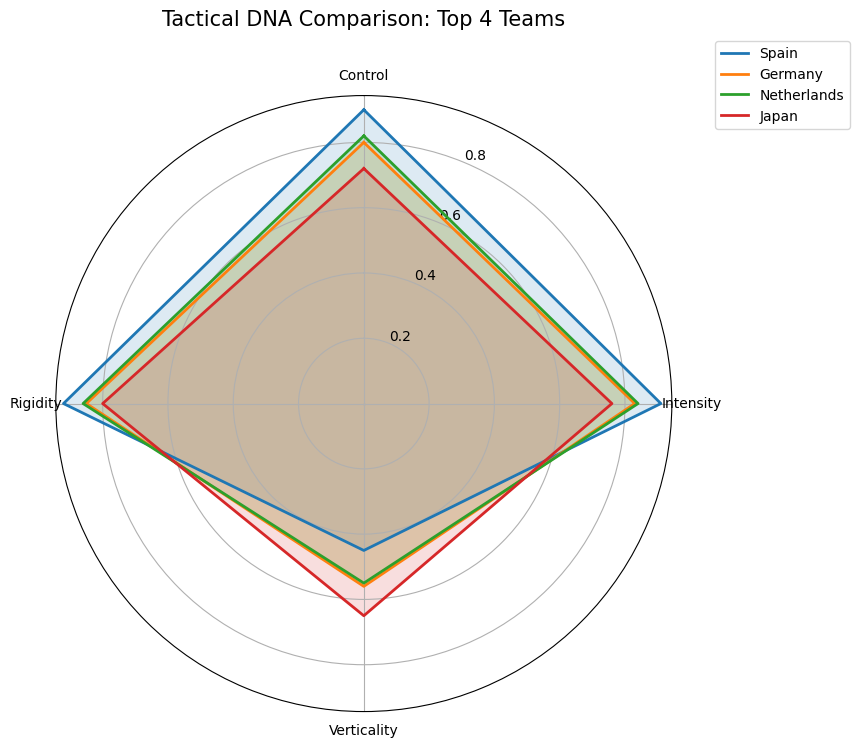

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dna_radar(df, top_n=4):
    # Select the top N teams by Rounds Played
    top_teams = df.head(top_n)
    categories = ['Control', 'Intensity', 'Verticality', 'Rigidity']
    num_vars = len(categories)

    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] # Close the circular plot

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for i, row in top_teams.iterrows():
        values = [row['DNA_Control'], row['DNA_Intensity'], row['DNA_Verticality'], row['DNA_Rigidity']]
        values += values[:1] # Close the plot
        ax.plot(angles, values, linewidth=2, label=row['Team'])
        ax.fill(angles, values, alpha=0.15)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), categories)
    plt.title("Tactical DNA Comparison: Top 4 Teams", size=15, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Execute the visualization
plot_dna_radar(df_report)

## H2E DNA Vector Comparison

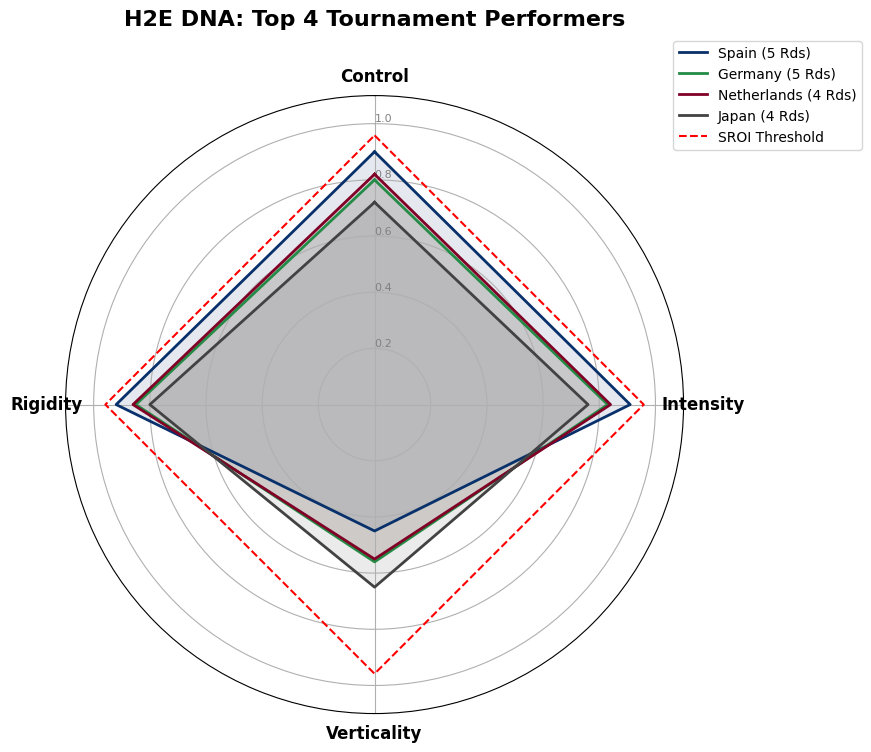

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def generate_dynamic_h2e_radar(df, threshold=0.9583):
    # 1. DYNAMIC SELECTION
    # We take the top 4 teams based on your existing df_report sorting
    top_4 = df.head(4).copy()

    # Define categories based on your DNA columns
    categories = ['DNA_Control', 'DNA_Intensity', 'DNA_Verticality', 'DNA_Rigidity']
    display_labels = ['Control', 'Intensity', 'Verticality', 'Rigidity']
    N = len(categories)

    # 2. RADAR CONFIGURATION
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

    # Rotate so first category is at the top
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Color palette for dynamic mapping
    colors = ['#08306b', '#238b45', '#800026', '#424242']

    # 3. DYNAMIC PLOTTING LOOP
    for i, (index, row) in enumerate(top_4.iterrows()):
        # Extract values dynamically from the DataFrame row
        values = [row[cat] for cat in categories]
        values += values[:1] # Close the loop

        team_name = row['Team']
        color = colors[i % len(colors)]

        ax.plot(angles, values, linewidth=2, label=f"{team_name} ({int(row['Rounds_Played'])} Rds)", color=color)
        ax.fill(angles, values, color=color, alpha=0.1)

    # 4. AESTHETICS & GOVERNANCE
    plt.xticks(angles[:-1], display_labels, color='black', size=12, weight='bold')
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2","0.4","0.6","0.8","1.0"], color="grey", size=8)
    plt.ylim(0, 1.1)

    # Dynamic Threshold Line
    ax.plot(angles, [threshold]*len(angles), color='red', linestyle='--', linewidth=1.5, label='SROI Threshold')

    plt.title(f'H2E DNA: Top {len(top_4)} Tournament Performers', size=16, y=1.1, weight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.show()

# EXECUTION
# This uses the df_report generated from your progression_map and NEZ_VAULT
generate_dynamic_h2e_radar(df_report)